# HLA read extraction from BAM

NA06985 is the public, already HLA-enriched SpecHLA exon example (52,771 pairs). BWA alignment to GRCh38 chromosome 6 creates the real sorted/indexed BAM. Extraction uses prepared tools with auto-installation off. The fixture does not exercise all whole-genome/CRAM or alternate-contig cases.

Prepare the dedicated environment and data using [the real-tool recipe](../benchmarks/real_tools/README.md). Set `IOBRX_REAL_WORK` to that work directory and launch Jupyter with the same environment. This notebook executes iobrx again in a fresh output directory. Its demonstration time is separate from the archived three-repeat benchmark. Tool logs stay in the work directory. No raw patient or private inputs are used.

In [1]:
import json, os, subprocess, sys, time, uuid
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "benchmarks/real_tools").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "benchmarks/real_tools").is_dir(), "Open from the repository or tutorials directory"
sys.path.insert(0, str(ROOT / "benchmarks/real_tools"))
WORK = Path(os.environ.get("IOBRX_REAL_WORK", str(ROOT / "real-tools-work"))).resolve()
assert (WORK / "cases.json").is_file(), "Run benchmarks/real_tools/prepare.py first"
config = json.loads((WORK / "cases.json").read_text())
from run import expand, scientific_products
from figures import make_figure


In [2]:
case = next(c for c in config["cases"] if c["function"] == 'extract_hla_read')
OUT = WORK / "notebook-runs" / ('27_real_hla_extraction' + "-" + uuid.uuid4().hex[:8])
OUT.mkdir(parents=True)
parameters = expand(case["parameters"], OUT)
# Public API equivalent: iobrx.extract_hla_read(**parameters)
# The tiny worker runs that call with the same interpreter; output goes to a log.
request = OUT.parent / (OUT.name + ".request.json")
request.write_text(json.dumps({"function": case["function"], "parameters": parameters}))
env = os.environ.copy()
env.update(OMP_NUM_THREADS="4", OPENBLAS_NUM_THREADS="4", MKL_NUM_THREADS="4", PYTHONHASHSEED="0", MPLBACKEND="Agg")
start = time.perf_counter()
with (OUT.parent / (OUT.name + ".log")).open("w") as log:
    subprocess.run([sys.executable, str(ROOT / "benchmarks/real_tools/arm.py"), str(request)],
                   env=env, stdout=log, stderr=subprocess.STDOUT, check=True)
demo_seconds = time.perf_counter() - start
products = scientific_products(OUT, case["function"])
print(f"Completed in {demo_seconds:.3f} s; inspected {len(products['files'])} scientific products")


Completed in 3.661 s; inspected 3 scientific products


In [3]:
evidence = json.loads((ROOT / "benchmarks/real_tools/results/2026-09-09/summary.json").read_text())
benchmark = next(c for c in evidence["cases"] if c["case"]["function"] == 'extract_hla_read'
                 and "single-thread" not in c["evidence_directory"])
local_summary = WORK / "repetitions" / 'extract_hla_read' / "summary.json"
if local_summary.is_file():
    benchmark = json.loads(local_summary.read_text())
display(pd.DataFrame([{"arm": r["arm"], "repeat": r["repeat"], "wall_seconds": r["wall_seconds"],
                       "peak_RSS_MiB": r["peak_rss_kib"] / 1024} for r in benchmark["runs"]]))
display(pd.DataFrame(benchmark["paired_comparisons"]))


,arm,repeat,wall_seconds,peak_RSS_MiB
0,iobrpy,1,3.758028,320.175781
1,iobrx,1,4.822295,121.492188
2,iobrx,2,4.866327,121.660156
3,iobrpy,2,3.804455,320.042969
4,iobrpy,3,4.821567,320.394531
5,iobrx,3,2.820020,121.562500


,repeat,equal,compared_products,different_products
0,1,True,3,[]
1,2,True,3,[]
2,3,True,3,[]


The left panel shows the archived, alternating three-repeat comparison, including process startup. The right panel uses this notebook's actual output. Setup, downloads, indexing and plotting are excluded from benchmark times. FASTQ comparison uses decompressed record bytes; STAR compares count files and sorted complete SAM records without headers; HLA typing compares the final allele report and all sixteen FASTAs. Logs and HTML timestamps are not scientific equality targets.

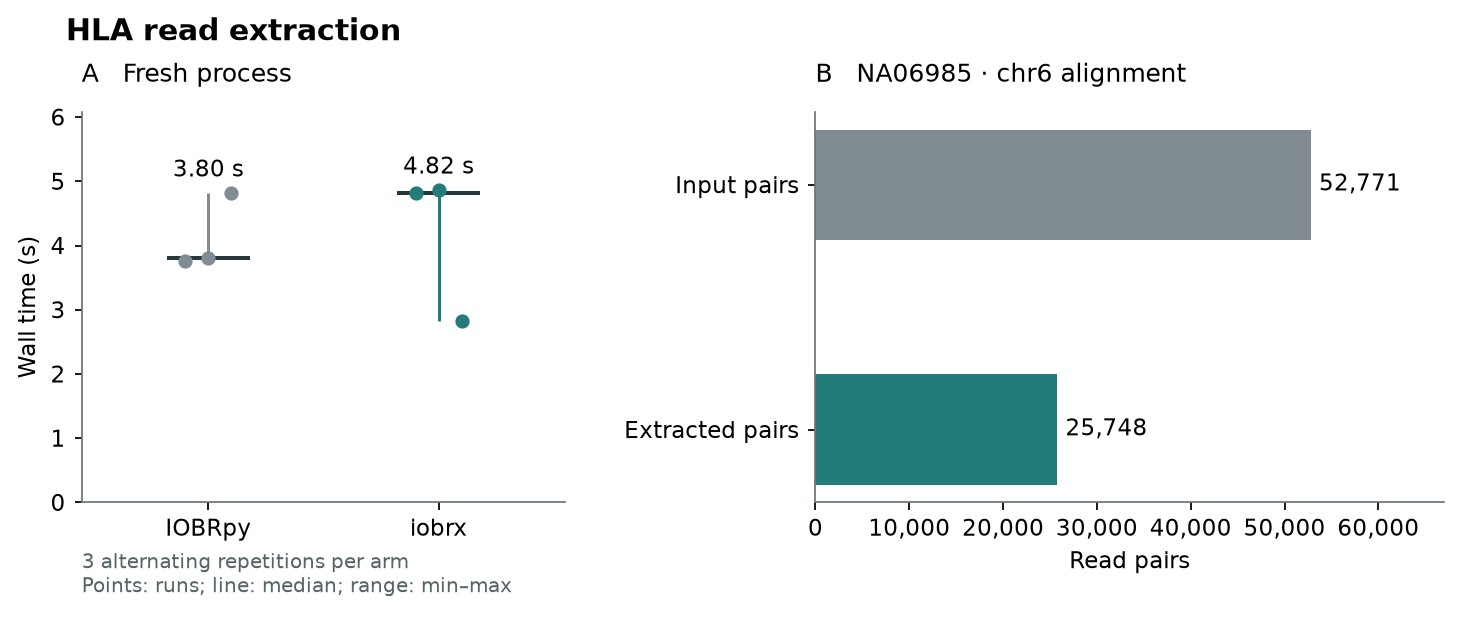

In [4]:
baseline_record = next(r for r in benchmark["runs"] if r["arm"] == "iobrpy")
baseline = Path(baseline_record["output"].replace("<WORK>", str(WORK)))
assert baseline.is_dir(), "Run the benchmark recipe to prepare original comparison outputs"
fig = make_figure(benchmark, OUT, baseline, revision=2)
# Export under a stable name; raw analysis outputs keep their unique run directory.
for extension in ("png", "pdf", "svg"):
    fig.savefig(ROOT / "tutorials/figures" / ('27_real_hla_extraction' + "." + extension), dpi=180, bbox_inches="tight")
display(Image(filename=str(ROOT / "tutorials/figures" / ('27_real_hla_extraction' + ".png"))))
import matplotlib.pyplot as plt
plt.close(fig)


See [source accessions, tools, limitations and full repetitions](../benchmarks/real_tools/README.md). These examples verify the declared inputs and outputs. They do not imply every workflow is faster, every multithreaded result is byte-identical, or HLA calls are independently validated.